In [28]:
from pathlib import Path
import mne

In [29]:
project_root = Path.cwd()
print("Current folder:", project_root)

Current folder: c:\seizure-detection-ML-project\notebooks


In [30]:
project_root = Path.cwd().parent
edf_path = project_root / "data" / "raw" / "chb01" / "chb01_03.edf"
print("Project root: ", project_root)
print("EDF file path: ", edf_path)
print("File exists: ", edf_path.exists())

Project root:  c:\seizure-detection-ML-project
EDF file path:  c:\seizure-detection-ML-project\data\raw\chb01\chb01_03.edf
File exists:  True


In [31]:
print("Path:", edf_path)
print("Exists:", edf_path.exists())
print("Size in bytes:", edf_path.stat().st_size)

with open(edf_path, "rb") as f:
    print("First 16 bytes:", f.read(16))

Path: c:\seizure-detection-ML-project\data\raw\chb01\chb01_03.edf
Exists: True
Size in bytes: 42399744
First 16 bytes: b'0       Surrogat'


In [32]:
raw = mne.io.read_raw_edf(
    edf_path,
    preload=False,
    verbose=False
)

print(raw)


<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~22 KiB, data not loaded>


C:\Users\rahma\AppData\Local\Temp\ipykernel_22076\1436170207.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [33]:
print(raw.info)
print("")
print(raw.ch_names)
print("")
print("Sampling frequency:", raw.info["sfreq"])

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

Sampling frequency: 256.0


In [34]:
for val, channel in enumerate(raw.ch_names):
    print(val, channel)

0 FP1-F7
1 F7-T7
2 T7-P7
3 P7-O1
4 FP1-F3
5 F3-C3
6 C3-P3
7 P3-O1
8 FP2-F4
9 F4-C4
10 C4-P4
11 P4-O2
12 FP2-F8
13 F8-T8
14 T8-P8-0
15 P8-O2
16 FZ-CZ
17 CZ-PZ
18 P7-T7
19 T7-FT9
20 FT9-FT10
21 FT10-T8
22 T8-P8-1


In [35]:
start = 0
stop = int(5 * raw.info["sfreq"])

data, times = raw.get_data(
    picks=["FP1-F7"],
    start = start,
    stop=stop,
    return_times=True
)

print("Data shape: ", data.shape)
print("Times shape:", times.shape)
print("First 10 data points:", data[0, :10])

Data shape:  (1, 1280)
Times shape: (1280,)
First 10 data points: [-1.77777778e-05  1.95360195e-07  1.95360195e-07  5.86080586e-07
  1.95360195e-07 -1.36752137e-06 -2.14896215e-06  5.86080586e-07
  2.93040293e-06 -5.86080586e-07]


In [36]:
data_uv = data[0] * 1e6
print("First 10 data points in microvolts:", data_uv[:10])


First 10 data points in microvolts: [-17.77777778   0.1953602    0.1953602    0.58608059   0.1953602
  -1.36752137  -2.14896215   0.58608059   2.93040293  -0.58608059]


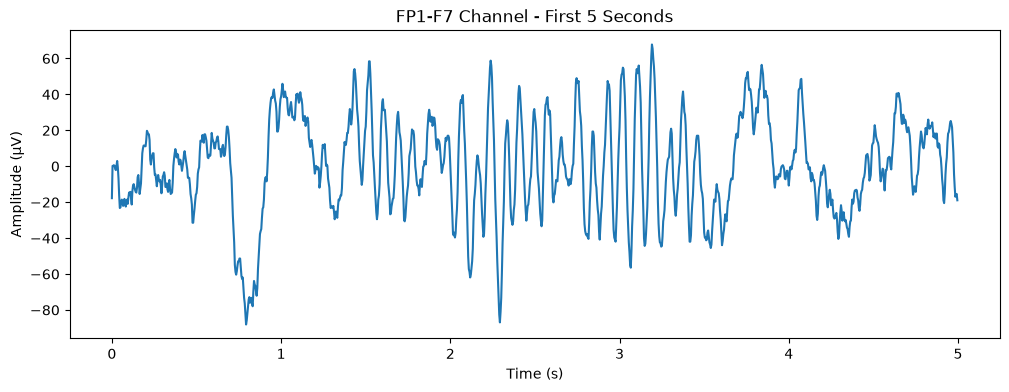

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(times, data_uv)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("FP1-F7 Channel - First 5 Seconds")
plt.show()      

In [38]:
summary_path = project_root / "data" / "raw" / "chb01" / "chb01-summary.txt"

print("Summary exists:", summary_path.exists())

Summary exists: True


In [39]:
summary_text  = summary_path.read_text()
start_index = summary_text.find("chb01_03.edf")
next_file_index = summary_text.find("File Name:", start_index + 1)
chb01_03_summary = summary_text[start_index:next_file_index]
print(chb01_03_summary)

chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds




In [40]:
summary_lines = chb01_03_summary.splitlines()
for line in summary_lines:
    print(line)

chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds



In [41]:

seizure_start = None
seizure_end = None

for line in summary_lines:
    if line.startswith("Seizure Start Time:"):
         seizure_start = int(line.split(":")[1].strip().split()[0]) 
        #this line extracts only the time value from the string
    if line.startswith("Seizure End Time:"):
            print("Seizure End Time: ", line)
            seizure_end  = int(line.split(":")[1].strip().split()[0]) 

print("Seizure start:", seizure_start)
print("Seizure end:", seizure_end)

Seizure End Time:  Seizure End Time: 3036 seconds
Seizure start: 2996
Seizure end: 3036


In [42]:
sfreq = raw.info["sfreq"]

seizure_start_sample = int(seizure_start * sfreq)
seizure_end_sample = int(seizure_end * sfreq)

print("Seizure start sample:", seizure_start_sample)
print("Seizure end sample:", seizure_end_sample)

Seizure start sample: 766976
Seizure end sample: 777216


In [43]:
seizure_data, seizure_times = raw.get_data(
    picks=["FP1-F7"],
    start=seizure_start_sample,
    stop=seizure_start_sample + int(5 * sfreq),  # Get 5 seconds of data after seizure start
    return_times=True
)

print("Seizure data shape: ", seizure_data.shape)
print("First time: ", seizure_times[0])    
print("Last time: ", seizure_times[-1])

Seizure data shape:  (1, 1280)
First time:  2996.0
Last time:  3000.99609375


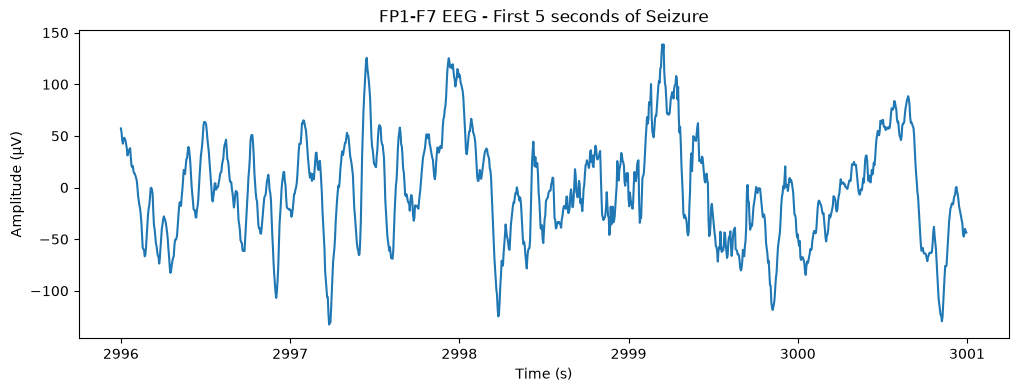

In [44]:
seizure_data_uv = seizure_data[0] * 1e6
plt.figure(figsize=(12, 4))
plt.plot(seizure_times, seizure_data_uv)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("FP1-F7 EEG - First 5 seconds of Seizure")
plt.show()

In [45]:
"""
So far we have:
-> Read data with MNE
-> Found seizure timing usingthe summary
-> converted seconds into sample indices
-> extracted FP1-F7 from 2996-3001 seconds (5 seconds) of seizure data
-> converted volts to microvolts
-> plotted the segment of seizure data
"""

'\nSo far we have:\n-> Read data with MNE\n-> Found seizure timing usingthe summary\n-> converted seconds into sample indices\n-> extracted FP1-F7 from 2996-3001 seconds (5 seconds) of seizure data\n-> converted volts to microvolts\n-> plotted the segment of seizure data\n'

In [46]:
print("Non seizure data mean: ", data_uv.mean())
print("Non seizure data std: ", data_uv.std())
print("")
print("Seizure data mean: ", seizure_data_uv.mean())
print("Seizure data std: ", seizure_data_uv.std())



Non seizure data mean:  0.4432234432234424
Non seizure data std:  27.234515605067216

Seizure data mean:  -1.7054334554334567
Seizure data std:  49.672727934927686


In [47]:
import numpy as np
#testing rms (Root Mean Square) feature - Gives us a signal amplitude; seizure readings tend to have higher aplitude

non_seizure_rms = np.sqrt(np.mean(data_uv**2))
seizure_rms = np.sqrt(np.mean(seizure_data_uv**2))

print("Non seizure RMS: ", non_seizure_rms)
print("Seizure RMS: ", seizure_rms)

Non seizure RMS:  27.238121948168022
Seizure RMS:  49.70199597368558


In [48]:
#test ptp (peak to peak) feature - Gives us the difference between the maximum and minimum values of the signal
non_seizure_ptp = np.ptp(data_uv)
seizure_ptp = np.ptp(seizure_data_uv)

print("Non seizure PTP Amplitude: ", non_seizure_ptp)
print("Seizure PTP Amplitude: ", seizure_ptp)

Non seizure PTP Amplitude:  155.89743589743588
Seizure PTP Amplitude:  271.15995115995116


In [49]:
import pandas as pd

feature_table = pd.DataFrame([
    {
    "Label": "Non Seizure",
     "mean_uv": data_uv.mean(),
     "std_uv": data_uv.std(),
     "rms_uv": non_seizure_rms,
     "ptp_uv": non_seizure_ptp
    },
     {"Label": "Seizure",
          "mean_uv": seizure_data_uv.mean(),
          "std_uv": seizure_data_uv.std(),
          "rms_uv": seizure_rms,
          "ptp_uv": seizure_ptp
     },

])

feature_table

,Label,mean_uv,std_uv,rms_uv,ptp_uv
0,Non Seizure,0.443223,27.234516,27.238122,155.897436
1,Seizure,-1.705433,49.672728,49.701996,271.159951


In [50]:
X = feature_table[["mean_uv", "std_uv", "rms_uv", "ptp_uv"]]
y = feature_table["Label"]
print("X: ")
print(X)
print("\ny: ")
print(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X: 
    mean_uv     std_uv     rms_uv      ptp_uv
0  0.443223  27.234516  27.238122  155.897436
1 -1.705433  49.672728  49.701996  271.159951

y: 
0    Non Seizure
1        Seizure
Name: Label, dtype: str
X shape: (2, 4)
y shape: (2,)


In [51]:
print("Features:")
display(X)

print("Labels:")
display(y)

Features:


,mean_uv,std_uv,rms_uv,ptp_uv
0,0.443223,27.234516,27.238122,155.897436
1,-1.705433,49.672728,49.701996,271.159951


Labels:


0    Non Seizure
1        Seizure
Name: Label, dtype: str

In this notebook, I loaded my first EEG recording, chb01_03, using MNE, inspected its sampling freq, its channels, extracted 5 seconds of seizure/non-seizure data, parsed the seizure timing from the summary file, and calculated different features including the mean, std, RMS, and peak-to-peak amplitude. I also organized these features into a ML-dataset where our features are represented as the inputs (x) that we may feed a model and the output(y) representing the seizure/non-seizure-label. 